Mounted at /content/drive


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 11.1762 - mae: 1.9561 - val_loss: 7.2533 - val_mae: 1.6805
Epoch 2/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7.7115 - mae: 1.8499 - val_loss: 4.1858 - val_mae: 1.4905
Epoch 3/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.2627 - mae: 1.3083 - val_loss: 2.0335 - val_mae: 0.9909
Epoch 4/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.6273 - mae: 0.8720 - val_loss: 0.6006 - val_mae: 0.4995
Epoch 5/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.1927 - mae: 0.6830 - val_loss: 0.2348 - val_mae: 0.3075
Epoch 6/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.8362 - mae: 0.5741 - val_loss: 0.1238 - val_mae: 0.2355
Epoch 7/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5742 - mae: 0.4621 - val_loss: 0.1526 - val_mae: 0.2687
Epoch 8/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5093 - mae: 0.4546 - val_loss: 0.1145 - val_mae: 0.2313
Epoch 9/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss

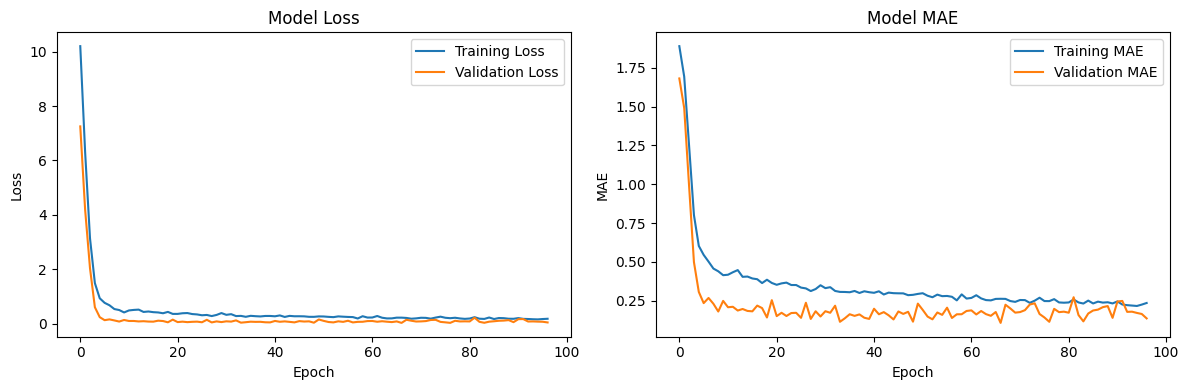

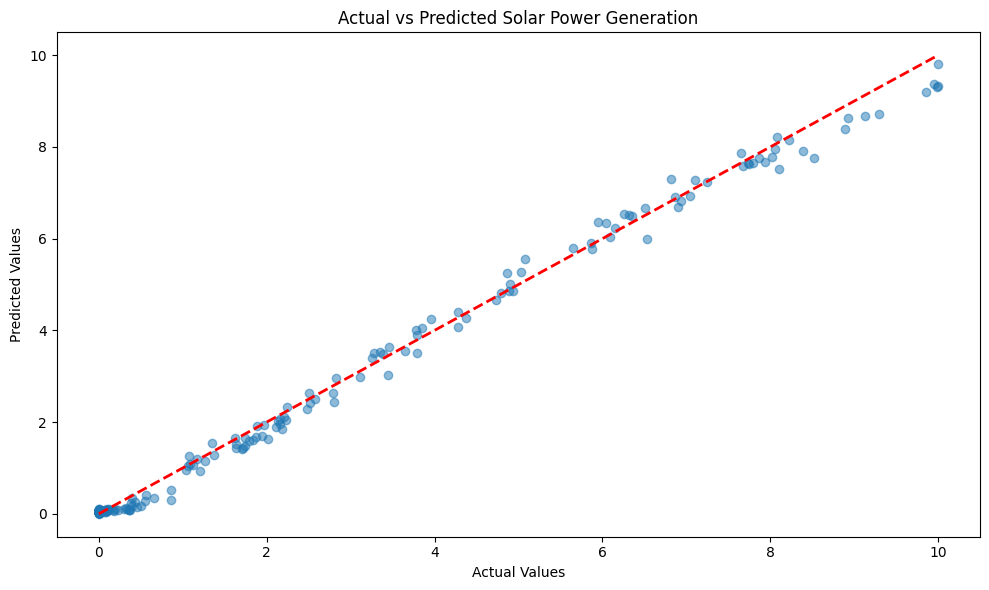

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive
import matplotlib.pyplot as plt
import os

# Mount Google Drive
drive.mount('/content/drive')

# Load the data
file_path = '/content/drive/My Drive/solar_power_10MW_output.xlsx'  # Update this path
data = pd.read_excel(file_path)

# Assuming the last column is the target (solar_power_mw)
X = data.iloc[:, :12].values  # 12 input columns
y = data.iloc[:, -1].values   # Last column as output

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build the model
model = Sequential([
    Dense(128, activation='relu', input_shape=(12,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1)
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train_scaled, y_train,
    epochs=300,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# Make predictions
predictions = model.predict(X_test_scaled)

# Calculate error metrics
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mse)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# Create a DataFrame with the results
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions.flatten()
})

# Save the results to Google Drive
output_path = '/content/drive/My Drive/solar_power_mw.xlsx'
results.to_excel(output_path, index=False)

print(f"Results saved to {output_path}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Solar Power Generation')
plt.tight_layout()
plt.show()